# Testing code cleanup and translation to C++ with chatGPT

In [36]:
# setting up
import os
import subprocess
from more_itertools import strip
import numpy as np
import seaborn as sea
import matplotlib.pyplot as plt
import pandas as pd
import re
import random

In [83]:
# shortcuts
home = '/Users/marniella/research/nielsen_lab/'
sims_folder_paths = {'verr_lower':home + 'project-extra-files/phylobc/step3_phylobc/sim_results_verr_lower/', 
                     'verr':home + 'project-extra-files/phylobc/step3_phylobc/sim_results_verr/', 
                     'cerr':home + 'project-extra-files/phylobc/step3_phylobc/sim_results_verr_compare/'}

In [12]:
# changing the script we're using
# phylobc_script = 'call_bases_from_pileup_pre_optimize.py'
phylobc_script = 'call_bases_from_pileup.py'

## On simulated reads

In [50]:
ansi_escape = re.compile(r'\x1B(?:[@-Z\\-_]|\[[0-?]*[ -/]*[@-~])')
# getting the paths to specific pileup files from the simulations (variable error)
verr_subfolders = subprocess.run('ls ' + sims_folder_paths['verr'], shell=True, stdout=subprocess.PIPE).stdout.decode('utf-8')
verr_subfolders = ansi_escape.sub('', verr_subfolders).strip().split('\n')
# same, lower variable error
verr_lower_subfolders = subprocess.run('ls ' + sims_folder_paths['verr_lower'], shell=True, stdout=subprocess.PIPE).stdout.decode('utf-8')
verr_lower_subfolders = ansi_escape.sub('', verr_lower_subfolders).strip().split('\n')
# getting the paths to specific pileup files from the simulations (constant error)
cerr_subfolders = subprocess.run('ls ' + sims_folder_paths['cerr'], shell=True, stdout=subprocess.PIPE).stdout.decode('utf-8')
cerr_subfolders = ansi_escape.sub('', cerr_subfolders).strip().split('\n')

subfolders = {'verr_lower':verr_lower_subfolders, 'verr':verr_subfolders, 'cerr':cerr_subfolders}

In [51]:
def get_cmd(subfolder, err_type): #err_type can be cerr, verr, verr_lower
    pileup_file = subfolder[12:] + '_sim_piledup.txt'
    pileup_results_path = sims_folder_paths[err_type] + subfolder + "/"
    return ' '.join(["./" + phylobc_script, pileup_file, pileup_results_path])

def run_accuracy_cmds(err_type):
    accuracy_cmd = open('get_accuracies_' + err_type +'.sh','w')
    accuracy_cmd.writelines('#!/bin/bash\n')
    run_script_cmds = [get_cmd(sf, err_type) for sf in subfolders[err_type]]
    accuracy_cmd.writelines(' & \n'.join(run_script_cmds))
    accuracy_cmd.close()
    subprocess.run('chmod +x get_accuracies_' + err_type + '.sh', shell=True)
    subprocess.run('{ time ./get_accuracies_' + err_type + '.sh >> accuracies_' + err_type + '.txt ; } 2> accuracies_' + err_type + '_time.txt', shell=True)

In [54]:
# running accuracy in the constant error simulations (at 0.5% -- i.e. ~150 bp will be wrong)
run_accuracy_cmds('cerr')
# running accuracy in the variable error simulations
run_accuracy_cmds('verr')
# running accuracy in the LOWER variable error simulations
run_accuracy_cmds('verr_lower')

In [32]:
title_abbrev = {'cerr':'constant 0.5% error', 'verr':'higher variable error', 'verr_lower':'lower variable error'}
def reshape_plot_accuracies(err_type):
    accuracy = pd.read_csv('accuracies_' + err_type + '.txt', header=None)
    accuracy.columns = ['file','prior','posterior','likelihood']
    accuracy['depth'] = [float(re.split('x_',f)[0]) for f in accuracy['file']]
    accuracy_long = pd.melt(accuracy, id_vars=['file','depth'], value_vars=['prior','posterior','likelihood'], var_name='calculation_type',value_name='accuracy')
    accuracy_long['n_wrong_bases'] = [int(b) for b in (30000*(1 - accuracy_long['accuracy']))]
    ax = sea.barplot(data = accuracy_long, x = 'depth', y = 'accuracy', hue = 'calculation_type')
    ax.set_title('Base calling on simulated reads (' + title_abbrev[err_type] + ')')
    return ax

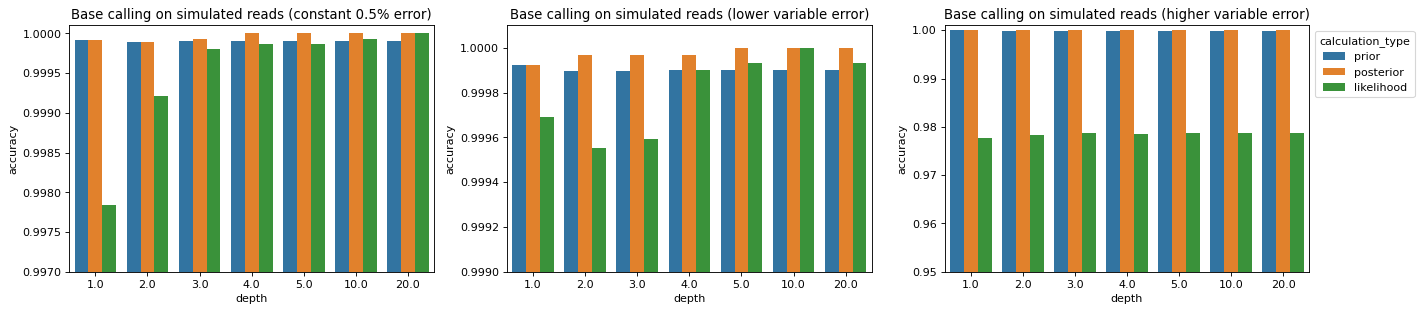

In [55]:
fig = plt.figure(figsize=(20, 4), dpi=80)

plt.subplot(1, 3, 1)
ax_cerr = reshape_plot_accuracies('cerr')
ax_cerr.set_ylim([0.997,1.0001])
ax_cerr.get_legend().remove()

plt.subplot(1, 3, 2)
ax_lower_verr = reshape_plot_accuracies('verr_lower')
ax_lower_verr.set_ylim([0.999,1.0001])
ax_lower_verr.get_legend().remove()

plt.subplot(1, 3, 3)
ax_verr = reshape_plot_accuracies('verr')
ax_verr.set_ylim([0.95,1.001])
sea.move_legend(ax_verr, "upper left", bbox_to_anchor=(1, 1))
plt.show()

## On reads downloaded from the SRA

In [84]:
# comparing consensus calls from bcftools vs. phylogenetic base calling
# order of columns is pp, pr, ll, bcf
raw_reads_folder = home + 'project-extra-files/phylobc/step3_phylobc/raw_read_results/'
mafft_t = pd.read_table(raw_reads_folder + "SRR25117579_calls_msa1t.txt")
mafft_t.head()

,---A
0,---T
1,TTTT
2,AAAA
3,AAAA
4,AAAA


We want to calculate the following metrics for each multiple sequence alignment (MSA):
+ true positives **(TP)**: incorrect bases that were changed
    + bcf and pp match; downsampled ll and/or error simulation did not support bcf and were changed
+ false positives **(FP)**: correct bases that were changed
    + bcf and pp *do not* match; downsampled ll and/or error simulation *supported* bcf but were changed
+ false negatives **(FN)**: incorrect bases that were left alone
    + bcf and pp *do not* match; downsampled ll and/or error simulation did not support bcf call and were not changed
+ true negatives **(TN)**: correct bases that were left alone
    + bcf and pp match; downsampled ll and/or error simulation *supported* bcf and were not changed

In [94]:
n=0
# metrics are TP, FP, FN, and TN
metrics = np.array([0,0,0,0])
with open(raw_reads_folder + "SRR25117579_calls_msa1t.txt") as f:
    for line in f:
        calls = list(line)
        # calls[0] is pp, calls[3] is bcf
        # calls[2] is ll
        n+=1
        metrics = np.add(
            metrics,
            np.array( [int(b) for b in [((calls[0] == calls[3]) & (calls[2] != calls[3])), ((calls[0] != calls[3]) & (calls[2] == calls[3])), 
                                        ((calls[0] != calls[3]) & (calls[2] != calls[3])), ((calls[0] == calls[3]) & (calls[2] == calls[3]))]
                        ] 
                    )
        ) 


In [98]:
metrics

array([    0,     1,    83, 29819])

In [99]:
# gain
metrics[0] - metrics[1]

-1